## 공통 실행
* 라이브러리 임포트
* 하이퍼 파라미터 설정
* 데이터 셋 불러오기
* 모델 학습 함수
* 모델 평가 함수

In [1]:
import numpy as np

import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, TensorDataset

import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models

import time
import datetime

In [2]:
num_classes = 10
num_epochs = 10
batchsize = 64
val_epoch = 1 # 매 몇 epoch마다 validation 할지

### 데이터셋 저장

#### 1) 데이터셋 ImageNet 평균으로 정규화

In [3]:
# CIFAR-10 데이터셋 불러오기

#CIFAR10 전체에 대한 평균 (R,G,B) : [0.4914, 0.4822, 0.4465]
#CIFAR10 전체에 대한 std (R,G,B) : [0.2470, 0.2435, 0.2616]

#Imagenet 평균 : [0.485, 0.456, 0.406]
#Imagenet std : [0.229, 0.224, 0.225]
# 엄밀히는 사전학습 가중치가 ImageNet으로 훈련되었기 때문에 이 값으로 정규화해야 하지만 값의 차이가 미미하여 비슷하다
# 원칙 : full fine-tuning이라면 ImageNet 통계, scratch 학습이라면 CIFAR-10 통계

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225))
]) # full fine tuning

transform_scratch = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=(0.4914, 0.4822, 0.4465), std=(0.2470, 0.2435, 0.2616))
])

In [4]:
# CIFAR-10 다운로드
trainset = torchvision.datasets.CIFAR10(root='./data', train=True,download=True, transform=transform)
testset = torchvision.datasets.CIFAR10(root='./data',train=False,download=True, transform=transform)

100%|██████████| 170M/170M [00:08<00:00, 21.0MB/s]


#### 2) Augmentation

In [ ]:
transform_aug = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225))
])

In [ ]:
# CIFAR-10 Augmented
trainset_aug = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform_aug)

### 공통 데이터로더

In [5]:
train_loader = DataLoader(trainset,batch_size=batchsize,shuffle=True)
test_loader = DataLoader(testset,batch_size=batchsize,shuffle=False)

### GPU

In [6]:
# GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

### 모델 학습 함수

In [15]:
def train_model(model, optimizer, num_epochs=10):
    history = {'loss': [], 'val_loss': [], 'accuracy': [], 'val_accuracy': []}
    start = time.time()

    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()

            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        train_loss = running_loss / len(train_loader)
        train_accuracy = correct / total ## 매번 계산 시키는 것은 효율 낭비 (수정 필요)

        # Test Dataset으로 성능 검토
        if (epoch-1) % val_epoch == 0:
          model.eval()
          val_loss = 0.0
          val_correct = 0
          val_total = 0

          with torch.no_grad():
              for inputs, labels in test_loader:
                  inputs, labels = inputs.to(device), labels.to(device)

                  outputs = model(inputs)
                  loss = criterion(outputs, labels)
                  val_loss += loss.item()

                  _, predicted = torch.max(outputs, 1)
                  val_total += labels.size(0)
                  val_correct += (predicted == labels).sum().item()

          val_loss /= len(test_loader)
          val_accuracy = val_correct / val_total

          history['loss'].append(train_loss)
          history['val_loss'].append(val_loss)
          history['accuracy'].append(train_accuracy)
          history['val_accuracy'].append(val_accuracy)

          sec = time.time() -start
          strtime = str(datetime.timedelta(seconds=sec)).split(".")[0]

          print(f'Epoch {epoch+1}/{num_epochs}|Loss:{train_loss:.4f}|Train Acc: {train_accuracy*100:.2f}%|Val(Test) Acc: {val_accuracy*100:.2f}%|Time:{strtime}')
    return history



### 모델 평가 함수

In [16]:
def evaluate_model(model):
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)

            outputs = model(inputs)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    accuracy = correct / total
    #print(f'Test Accuracy: {accuracy * 100:.2f}%')
    return accuracy



## 1. ResNet 모델을 불러와 새로운 이미지 데이터셋을 분류하세요.

### 1 - Training from scratch


#### 1) resnet50

In [ ]:
# ResNet50 load without weights (구조만을 가져와서 학습)
base_model=models.resnet50(weights=None)
# 전역 평균 풀링 레이어 추가를 위해 하위 두 레이어 제거
base_model=nn.Sequential(*list(base_model.children())[:-2])
# nn.Sequential은 파이썬의 리스트를 인자로 받지 못하기때문에 *를 이용하여 unpack 해줘서 각각의 층을 독립된 인자로 전달한다.

model_name = 'ResNet50 Training from scratch'

In [ ]:
# 모델 구축
class CustomResNet50(nn.Module):
  def __init__(self, num_classes):
    super(CustomResNet50, self).__init__()
    self.base_model = base_model #resnet50에서 마지막 두 레이어 제거한 구조
    self.global_avg_pool = nn.AdaptiveAvgPool2d((1,1)) # (1,1): output size
    self.fc1 = nn.Linear(2048, 256)
    self.relu = nn.ReLU()
    self.fc2 = nn.Linear(256, num_classes)
    self.softmax = nn.Softmax(dim=1)

  def forward(self,x): # input (3, 32,32)
    x = self.base_model(x) #32->16->8->4->2->1 => Nx2048x1x1
    x = self.global_avg_pool(x)         # N x 2048 x 1 x 1 # avgpool 의미없는 상태
    x = torch.flatten(x, 1) # start_dim =1  #N x 2048
    x = self.relu(self.fc1(x))          # N x 256
    x = self.fc2(x)                     # N x 10
    x = self.softmax(x) #확률
    return x

In [ ]:
custom_resnet50 = CustomResNet50(num_classes=num_classes)

In [ ]:
# GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
custom_resnet50 = custom_resnet50.to(device)

In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(
    filter(lambda p: p.requires_grad, custom_resnet50.parameters()), lr=1e-3)

In [ ]:
# 모델 훈련
custom_resnet50_history = train_model(custom_resnet50, optimizer, num_epochs)
print()
# 모델 평가
accuracy = evaluate_model(custom_resnet50)
print(f'{model_name} Test Accuracy: {accuracy * 100:.2f}%')

Epoch 1/10|Loss: 2.1956|Val(Test) Accuracy: 0.2771|Time:0:01:01
Epoch 2/10|Loss: 2.1188|Val(Test) Accuracy: 0.2711|Time:0:02:01
Epoch 3/10|Loss: 2.0984|Val(Test) Accuracy: 0.4010|Time:0:03:01
Epoch 4/10|Loss: 2.0602|Val(Test) Accuracy: 0.4153|Time:0:04:01
Epoch 5/10|Loss: 2.0610|Val(Test) Accuracy: 0.4219|Time:0:05:01
Epoch 6/10|Loss: 2.0324|Val(Test) Accuracy: 0.4307|Time:0:06:13
Epoch 7/10|Loss: 2.0529|Val(Test) Accuracy: 0.4309|Time:0:07:25
Epoch 8/10|Loss: 2.0478|Val(Test) Accuracy: 0.4305|Time:0:08:28
Epoch 9/10|Loss: 2.0439|Val(Test) Accuracy: 0.4325|Time:0:09:29
Epoch 10/10|Loss: 1.9969|Val(Test) Accuracy: 0.4830|Time:0:10:30
ResNet50 Training from scratch Test Accuracy: 48.30%


### 2 - Full Fine Tuning

requires_grad=False 안해주면 사전 훈련 가중치를 시작점으로만 쓰고, 모든 레이어를 새 데이터로 업데이트

#### 1) resnet18

In [ ]:
resnet18 = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
# Modify FCL
resnet18.fc = nn.Linear(resnet18.fc.in_features, num_classes)

model_name = 'ResNet18'

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 142MB/s]


In [ ]:
# GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
resnet18 = resnet18.to(device)

In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(
    filter(lambda p: p.requires_grad, resnet18.parameters()), lr=1e-3)

In [ ]:
# 모델 훈련
resnet18_history = train_model(resnet18, optimizer, num_epochs)

In [ ]:
# 모델 resnet18 평가
accuracy = evaluate_model(resnet18)
print(f'{model_name} Test Accuracy: {accuracy * 100:.2f}%')

#### 2) resnet50

In [ ]:
resnet50 = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)
# Modify FCL
resnet50.fc = nn.Linear(resnet50.fc.in_features, 10)

model_name = 'ResNet50'

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 204MB/s]


In [ ]:
# GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
resnet50 = resnet50.to(device)

In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(
    filter(lambda p: p.requires_grad, resnet50.parameters()), lr=1e-3)

In [ ]:
# 모델 훈련
resnet50_history = train_model(resnet50, optimizer, num_epochs)


Epoch 1/10|Loss: 0.8415|Val(Test) Accuracy: 0.7946|Time:0:00:58
Epoch 2/10|Loss: 0.5263|Val(Test) Accuracy: 0.8237|Time:0:02:00
Epoch 3/10|Loss: 0.4169|Val(Test) Accuracy: 0.8389|Time:0:03:00
Epoch 4/10|Loss: 0.3387|Val(Test) Accuracy: 0.8299|Time:0:04:04
Epoch 5/10|Loss: 0.2860|Val(Test) Accuracy: 0.8231|Time:0:05:04
Epoch 6/10|Loss: 0.2396|Val(Test) Accuracy: 0.8481|Time:0:06:05
Epoch 7/10|Loss: 0.2035|Val(Test) Accuracy: 0.8442|Time:0:07:06
Epoch 8/10|Loss: 0.1746|Val(Test) Accuracy: 0.8405|Time:0:08:08
Epoch 9/10|Loss: 0.1477|Val(Test) Accuracy: 0.8481|Time:0:09:16
Epoch 10/10|Loss: 0.1318|Val(Test) Accuracy: 0.8468|Time:0:10:24


In [ ]:
# 모델 평가
accuracy = evaluate_model(resnet50)
print(f'{model_name} Test Accuracy: {accuracy * 100:.2f}%')

ResNet50 Test Accuracy: 84.68%


### 3) 레이어 변경


#### resnet50 : conv1 수정, maxpool 제거

In [9]:
customized_model = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)

customized_model.conv1 = nn.Conv2d(3, 64, kernel_size=3, padding=1, bias=False) # 크기 유지
customized_model.maxpool =  nn.Identity() #maxpool layer 하나밖에 없음 (맨 위)
customized_model.fc = nn.Linear(customized_model.fc.in_features, 10)

#3,32,32 > layer 2에서 downsample 512,16,16 > layer3에서 downsample 1024,8,8
#layer4에서 downsample 2048,4,4 > avgpool 2048,1,1

model_name = 'ResNet50 Customized Layer for CIFAR-10'

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 157MB/s]


In [10]:
customized_model = customized_model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(
    filter(lambda p: p.requires_grad, customized_model.parameters()), lr=1e-3)

In [11]:
# 모델 훈련
customized_resnet50_history = train_model(customized_model, optimizer, num_epochs)
print()
# 모델 평가
accuracy = evaluate_model(customized_model)
print(f'{model_name} Test Accuracy: {accuracy * 100:.2f}%')

Epoch 1/10|Loss: 0.7097|Val(Test) Accuracy: 0.8309|Time:0:02:56
Epoch 2/10|Loss: 0.3456|Val(Test) Accuracy: 0.8744|Time:0:05:57
Epoch 3/10|Loss: 0.2350|Val(Test) Accuracy: 0.8885|Time:0:08:59
Epoch 4/10|Loss: 0.1698|Val(Test) Accuracy: 0.8746|Time:0:12:00
Epoch 5/10|Loss: 0.1252|Val(Test) Accuracy: 0.8981|Time:0:15:01
Epoch 6/10|Loss: 0.1003|Val(Test) Accuracy: 0.8992|Time:0:18:02
Epoch 7/10|Loss: 0.0857|Val(Test) Accuracy: 0.8937|Time:0:21:04
Epoch 8/10|Loss: 0.0732|Val(Test) Accuracy: 0.8955|Time:0:24:05
Epoch 9/10|Loss: 0.0614|Val(Test) Accuracy: 0.8866|Time:0:27:06
Epoch 10/10|Loss: 0.0571|Val(Test) Accuracy: 0.8841|Time:0:30:08

ResNet50 Customized Layer for CIFAR-10 Test Accuracy: 88.41%


## 2. 이미지 데이터셋과 사전 훈련된 VGG16 모델을 가져와 전이 학습을 수행하세요.

### 1) Partial finetuning
output layer만 수정

In [ ]:
vgg_partial = models.vgg16(weights=models.VGG16_Weights.DEFAULT)
# parameter fixed 고정. Don't train
for param in vgg_partial.parameters():
  param.requires_grad = False

# modify output layer
num_ftrs = vgg_partial.classifier[6].in_features
vgg_partial.classifier[6] = nn.Linear(num_ftrs, num_classes)

model_name = 'Vgg_Partial_Fine'

Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:06<00:00, 89.4MB/s]


In [ ]:
# GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
vgg_partial = vgg_partial.to(device)

In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(
    filter(lambda p: p.requires_grad, vgg_partial.parameters()), lr=1e-3)

In [ ]:
# 모델 훈련
vgg_partial_history = train_model(vgg_partial, optimizer, num_epochs)
print()
# 모델 평가
accuracy = evaluate_model(vgg_partial)
print(f'{model_name} Test Accuracy: {accuracy * 100:.2f}%')

Epoch 1/10|Loss: 1.4871|Val(Test) Accuracy: 0.6207|Time:0:00:31
Epoch 2/10|Loss: 1.4936|Val(Test) Accuracy: 0.6112|Time:0:00:58
Epoch 3/10|Loss: 1.5156|Val(Test) Accuracy: 0.6105|Time:0:01:26
Epoch 4/10|Loss: 1.5337|Val(Test) Accuracy: 0.6245|Time:0:01:53
Epoch 5/10|Loss: 1.5361|Val(Test) Accuracy: 0.6165|Time:0:02:20
Epoch 6/10|Loss: 1.5357|Val(Test) Accuracy: 0.6167|Time:0:02:48
Epoch 7/10|Loss: 1.5438|Val(Test) Accuracy: 0.6204|Time:0:03:18
Epoch 8/10|Loss: 1.5357|Val(Test) Accuracy: 0.6095|Time:0:03:51
Epoch 9/10|Loss: 1.5413|Val(Test) Accuracy: 0.6255|Time:0:04:21
Epoch 10/10|Loss: 1.5333|Val(Test) Accuracy: 0.6163|Time:0:04:53

Vgg_Partial_Fine Test Accuracy: 61.63%


### 2) Full Fine Tuning

In [ ]:
vgg_full = models.vgg16(weights=models.VGG16_Weights.DEFAULT)

# modify output layer
num_ftrs = vgg_full.classifier[6].in_features
vgg_full.classifier[6] = nn.Linear(num_ftrs, num_classes)

model_name = 'Vgg_Full'

In [ ]:
vgg_full = vgg_full.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(
    filter(lambda p: p.requires_grad, vgg_full.parameters()), lr=1e-3)

In [ ]:
# 모델 훈련
vgg_full_history = train_model(vgg_full, optimizer, num_epochs)
print()
# 모델 평가
accuracy = evaluate_model(vgg_full)
print(f'{model_name} Test Accuracy: {accuracy * 100:.2f}%')

Epoch 1/10|Loss: 1.8471|Val(Test) Accuracy: 0.3681|Time:0:01:16
Epoch 2/10|Loss: 1.3454|Val(Test) Accuracy: 0.5418|Time:0:02:39
Epoch 3/10|Loss: 1.0689|Val(Test) Accuracy: 0.5767|Time:0:04:03
Epoch 4/10|Loss: 0.9171|Val(Test) Accuracy: 0.6984|Time:0:05:27
Epoch 5/10|Loss: 0.8036|Val(Test) Accuracy: 0.7162|Time:0:06:44
Epoch 6/10|Loss: 0.7838|Val(Test) Accuracy: 0.7243|Time:0:08:01
Epoch 7/10|Loss: 0.6825|Val(Test) Accuracy: 0.7333|Time:0:09:17
Epoch 8/10|Loss: 0.6728|Val(Test) Accuracy: 0.7678|Time:0:10:33
Epoch 9/10|Loss: 0.6512|Val(Test) Accuracy: 0.7543|Time:0:11:49
Epoch 10/10|Loss: 0.6481|Val(Test) Accuracy: 0.7701|Time:0:13:08

Vgg_Full Test Accuracy: 77.01%


## 3. 동일한 데이터셋에서 ResNet과 VGG16을 각각 학습시켜 성능을 비교하세요

### Full Fine Tuning (No Freeze)

In [12]:
resnet18 = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
resnet18.fc = nn.Linear(resnet18.fc.in_features, num_classes)

vgg16 = models.vgg16(weights=models.VGG16_Weights.DEFAULT)
vgg16.classifier[6] = nn.Linear(vgg16.classifier[6].in_features, num_classes)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 180MB/s]


Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:07<00:00, 75.0MB/s]


In [17]:
resnet18 = resnet18.to(device)
vgg16 = vgg16.to(device)

criterion = nn.CrossEntropyLoss()
resnet18_optimizer = torch.optim.Adam(
    filter(lambda p: p.requires_grad, resnet18.parameters()), lr=1e-3)

vgg16_optimizer = torch.optim.Adam(
    filter(lambda p: p.requires_grad, vgg16.parameters()), lr=1e-3)

In [18]:
# 모델 resnet 훈련
resnet18_history = train_model(resnet18, resnet18_optimizer)  # 1epoch 37sec
print()
# 모델 vgg 훈련
vgg16_history = train_model(vgg16, vgg16_optimizer) # 1epoch 1:21

Epoch 1/10|Loss:0.6066|Train Acc: 79.61%|Val(Test) Acc: 77.75%|Time:0:00:35
Epoch 2/10|Loss:0.4647|Train Acc: 84.26%|Val(Test) Acc: 80.08%|Time:0:01:12
Epoch 3/10|Loss:0.3691|Train Acc: 87.51%|Val(Test) Acc: 78.73%|Time:0:01:46
Epoch 4/10|Loss:0.2884|Train Acc: 90.27%|Val(Test) Acc: 80.54%|Time:0:02:21
Epoch 5/10|Loss:0.2225|Train Acc: 92.41%|Val(Test) Acc: 79.87%|Time:0:02:56
Epoch 6/10|Loss:0.1798|Train Acc: 93.76%|Val(Test) Acc: 80.20%|Time:0:03:31
Epoch 7/10|Loss:0.1590|Train Acc: 94.56%|Val(Test) Acc: 80.42%|Time:0:04:07
Epoch 8/10|Loss:0.1243|Train Acc: 95.71%|Val(Test) Acc: 80.97%|Time:0:04:43
Epoch 9/10|Loss:0.1008|Train Acc: 96.56%|Val(Test) Acc: 79.78%|Time:0:05:18
Epoch 10/10|Loss:0.0990|Train Acc: 96.60%|Val(Test) Acc: 80.10%|Time:0:05:53

Epoch 1/10|Loss:1.7723|Train Acc: 29.50%|Val(Test) Acc: 38.03%|Time:0:01:18
Epoch 2/10|Loss:1.3735|Train Acc: 47.32%|Val(Test) Acc: 48.07%|Time:0:02:35
Epoch 3/10|Loss:1.2079|Train Acc: 55.80%|Val(Test) Acc: 58.68%|Time:0:03:53
Epoch 4/10

In [19]:
# 모델 평가
resnet18_accuracy = evaluate_model(resnet18)
vgg16_accuracy = evaluate_model(vgg16)

# 정확도 비교
print(f"Resnet18 Accuracy: {resnet18_accuracy *100:.2f}%")
print(f"Vgg16 Accuracy: {vgg16_accuracy * 100:.2f}%")

if resnet18_accuracy > vgg16_accuracy:
    print("Resnet18 has better accuracy than Vgg16.")
else:
    print("Vgg16 has better accuracy than Resnet18.")


Resnet18 Accuracy: 80.10%
Vgg16 Accuracy: 67.86%
Resnet18 has better accuracy than Vgg16.


Text(0.5, 1.0, 'Train Loss')

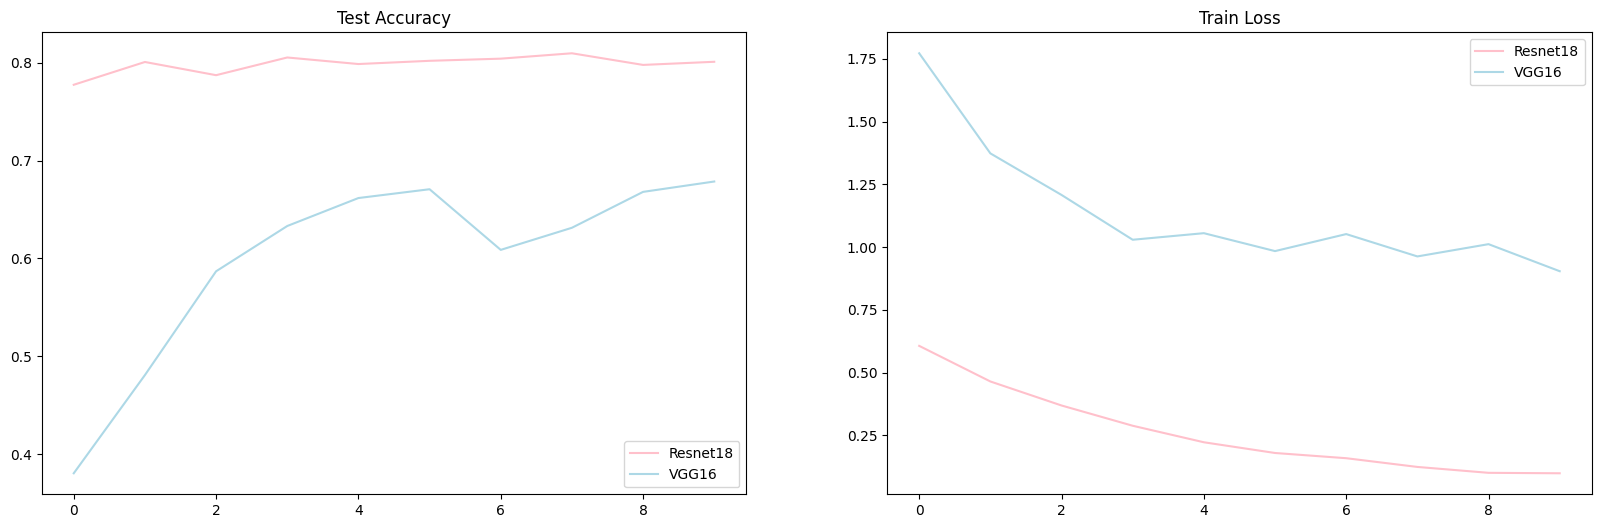

In [23]:
# 그래프
import matplotlib.pyplot as plt

f, axes = plt.subplots(1,2, figsize=(20,6))

axes[0].plot(resnet18_history['val_accuracy'], color='pink', label='Resnet18')
axes[0].plot(vgg16_history['val_accuracy'], color='lightblue', label='VGG16')
axes[0].legend()
axes[0].set_title('Test Accuracy')

axes[1].plot(resnet18_history['loss'], color='pink', label='Resnet18')
axes[1].plot(vgg16_history['loss'], color='lightblue', label='VGG16')
axes[1].legend()
axes[1].set_title('Train Loss')

## 4. 가상 데이터셋을 생성한 뒤, GridSearch 와 RandomSearch 기법으로 하이퍼파라미터 튜닝을 진행하세요.

In [21]:
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.datasets import make_classification
from scipy.stats import randint

# 가상의 데이터셋
X,y = make_classification(n_samples=1000, n_features=20,n_informative=2,n_redundant=10,random_state=42)
X_train, X_test, y_train, y_test=train_test_split(X,y,test_size=0.2,random_state=42)

#Hyperparameter Grid
param_grid = {
    'n_estimators':[50,100,200],
    'max_depth':[10,20,30],
    'min_samples_split':[2,5,10]
}

#Hyperparameter Random
param_dist = {
    'n_estimators': randint(50,200), #(low, high) distribution
    'max_depth':randint(10,30),
    'min_samples_split':randint(2,10)
}

#Random Forest Model
model = RandomForestClassifier(random_state=42)

#Set Gridsearch
grid_search = GridSearchCV(estimator=model, param_grid=param_grid, cv=5, scoring='accuracy')
grid_search.fit(X_train,y_train)
print("Grid Search Best Hyperparameters:",grid_search.best_params_)
best_grid_model = grid_search.best_estimator_
train_accuracy_grid = best_grid_model.score(X_train,y_train)
test_accuracy_grid = best_grid_model.score(X_test, y_test)
print(f"Tuned Model with Grid Search - Train Accuracy: {train_accuracy_grid}, Test Accuracy:{test_accuracy_grid}")

#Set Randomsearch
random_search = RandomizedSearchCV(estimator=model,param_distributions=param_dist,
                                   n_iter=100, cv=5, scoring='accuracy',random_state=42)
random_search.fit(X_train, y_train)
print("Random Search Best Hyperparamters:",random_search.best_params_)
best_random_model = random_search.best_estimator_
train_accuracy_ran = best_random_model.score(X_train, y_train)
test_accuracy_ran = best_random_model.score(X_test, y_test)
print(f"Tuned Model with Grid Search - Train Accuracy: {train_accuracy_ran}, Test Accuracy:{test_accuracy_ran}")


Grid Search Best Hyperparameters: {'max_depth': 20, 'min_samples_split': 10, 'n_estimators': 100}
Tuned Model with Grid Search - Train Accuracy: 0.96375, Test Accuracy:0.925
Random Search Best Hyperparamters: {'max_depth': 10, 'min_samples_split': 6, 'n_estimators': 191}
Tuned Model with Grid Search - Train Accuracy: 0.97625, Test Accuracy:0.92
